Goal: Predict the probability that a wildfire will threaten an evacuation zone within 12, 24, 48, and 72 hours, drawing on data from just the first five hours after ignition.

The goal is not a single prediction but a calibrated forecast across multiple time horizons. Emergency responders need both urgency rankings (which fires demand immediate attention) and probability estimates they can trust when making high-stakes decisions about evacuations, resource deployment, and public alerts.


Ex: Prob it hits within 12 hrs = Pr(time it hits <= 12) = 1 - Pr(time hits > 12) --> survival funct.

Intervals: does fire hit in interval (0,12) (12, 24) (24,48) (48-72)

In [ ]:
from google.colab import drive
import pandas as pd
!pip install lightgbm --quiet
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

HORIZONS = [12, 24, 48, 72]
SEED = 42

In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
file_path_train = '/content/drive/MyDrive/WiDs Datathon/train.csv'
train_df = pd.read_csv(file_path_train)
train_df.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [ ]:
file_path_test = '/content/drive/MyDrive/WiDs Datathon/test.csv'
test_df = pd.read_csv(file_path_test)

In [ ]:
def categorize_hit_time(row):
    if row['event'] == 1:
        time_to_hit = row['time_to_hit_hours']
        if 0 < time_to_hit <= 12:
            return 1
        elif 12 < time_to_hit <= 24:
            return 2
        elif 24 < time_to_hit <= 48:
            return 3
        elif 48 < time_to_hit <= 72:
            return 4
    return 0

train_df['hit_time_category'] = train_df.apply(categorize_hit_time, axis=1)

train_df.drop(columns=['time_to_hit_hours', 'event'], inplace=True)


In [ ]:
train_df.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,hit_time_category
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,2
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,7.965118e-14,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000e+00,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,0


In [22]:
DROP_FEATURES = ['event_start_dayofweek', 'event_start_hour', 'event_start_month']

X = train_df.drop(columns=['event_id', 'hit_time_category'] + DROP_FEATURES)
X_test = test_df[X.columns]
cat = train_df['hit_time_category']

horizon_labels = {
    12: (cat == 1).astype(int),                        # only 0-12h fires
    24: (cat.isin([1, 2])).astype(int),                # hit by 24h
    48: (cat.isin([1, 2, 3])).astype(int),             # hit by 48h
    72: (cat.isin([1, 2, 3, 4])).astype(int),          # hit by 72h (any hit)
}

for h, labels in horizon_labels.items():
    print(f'Horizon {h:2d}h — hit rate: {labels.mean():.3f}  ({labels.sum()} fires)')

Horizon 12h — hit rate: 0.222  (49 fires)
Horizon 24h — hit rate: 0.285  (63 fires)
Horizon 48h — hit rate: 0.299  (66 fires)
Horizon 72h — hit rate: 0.312  (69 fires)


In [38]:
from sklearn.calibration import CalibratedClassifierCV

for h in HORIZONS:
    calibrated = CalibratedClassifierCV(lgb.LGBMClassifier(**lgb_params),
                                         method='sigmoid', cv=5)
    calibrated.fit(X, horizon_labels[h])
    models[h] = calibrated

In [39]:
lgb_params = {
    'objective':        'binary',
    'metric':           'auc',
    'n_estimators':     2000,
    'learning_rate':    0.005,
    'num_leaves':       31,
    'min_child_samples': 5,
    'subsample':        0.7,
    'colsample_bytree': 0.7,
    'reg_alpha':        1.0,
    'reg_lambda':       5.0,
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

models = {}

for h in HORIZONS:
    y_h = horizon_labels[h]

    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y_h, test_size=0.2, stratify=y_h, random_state=SEED
    )

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    models[h] = model
    print(f'Horizon {h:2d}h — Val AUC: {val_auc:.4f}  |  Best iter: {model.best_iteration_}')

Horizon 12h — Val AUC: 0.9800  |  Best iter: 6
Horizon 24h — Val AUC: 0.9760  |  Best iter: 98
Horizon 48h — Val AUC: 0.9856  |  Best iter: 5
Horizon 72h — Val AUC: 1.0000  |  Best iter: 3


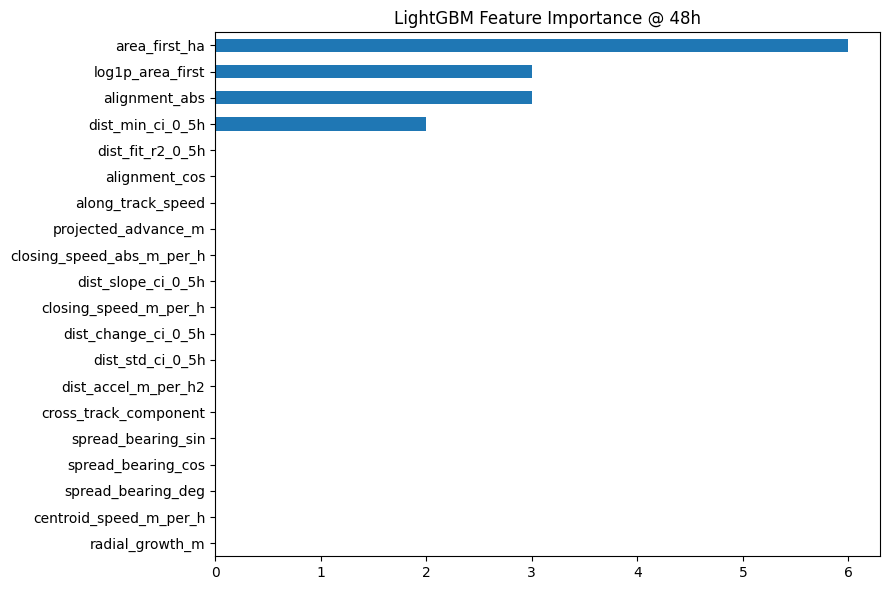

In [40]:
import matplotlib.pyplot as plt

fi = pd.Series(
    models[48].feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(20)

fi.plot(kind='barh', figsize=(9, 6))
plt.title('LightGBM Feature Importance @ 48h')
plt.tight_layout()
plt.show()

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

horizon_labels = {
    12: (cat == 1).astype(int),
    24: (cat.isin([1, 2])).astype(int),
    48: (cat.isin([1, 2, 3])).astype(int),
    72: (cat.isin([1, 2, 3, 4])).astype(int),
}

for h in HORIZONS:
    y_h = horizon_labels[h]
    model_cv = lgb.LGBMClassifier(**lgb_params)
    scores = cross_val_score(model_cv, X, y_h, cv=SKF, scoring='roc_auc')
    print(f'Horizon {h:2d}h — Mean AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Horizon 12h — Mean AUC: 0.9581 ± 0.0349
Horizon 24h — Mean AUC: 0.9900 ± 0.0104
Horizon 48h — Mean AUC: 0.9955 ± 0.0048
Horizon 72h — Mean AUC: 0.9990 ± 0.0020


In [42]:
# retraining on all data
for h in HORIZONS:
    y_h = horizon_labels[h]
    models[h] = lgb.LGBMClassifier(**lgb_params)
    models[h].fit(X, y_h)  # full data, no eval set
    print(f'Horizon {h:2d}h — done')

Horizon 12h — done
Horizon 24h — done
Horizon 48h — done
Horizon 72h — done


In [43]:
X_test = test_df[X.columns]

submission = pd.DataFrame({'event_id': test_df['event_id']})

probs = {}
for h in HORIZONS:
    probs[h] = models[h].predict_proba(X_test)[:, 1]
    submission[f'prob_{h}h'] = probs[h]

for i, h in enumerate(HORIZONS[1:], 1):
    prev_h = HORIZONS[i-1]
    submission[f'prob_{h}h'] = submission[[f'prob_{prev_h}h', f'prob_{h}h']].max(axis=1)

for h in HORIZONS:
    submission[f'prob_{h}h'] = submission[f'prob_{h}h'].clip(0.001, 0.999)

SAVE_PATH = '/content/drive/MyDrive/WiDs Datathon/submission.csv'
submission.to_csv(SAVE_PATH, index=False)
print(f'Saved {len(submission)} rows')
submission.head()

Saved 95 rows


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.010693,0.010898,0.011150,0.014275
1,13353600,0.684518,0.933990,0.945309,0.957997
2,13942327,0.011726,0.011726,0.011726,0.015659
3,16112781,0.603144,0.895065,0.945309,0.957997
4,17132808,0.038391,0.038391,0.038391,0.038391


4 independent LightGBM binary classifiers were trained with one per prediction horizon. each predicting cumulative probability of a fire hitting by that horizon using censor aware labels.

**12h model:** label = 1 if category = 1

**24h model:** label = 1 if category exists in category 1 or 2

**48h model:** label = 1 if category exists in category 1, 2, or 3.

**72h model:** label = 1 if category exists in category 1, 2, 3, or 4.

**predictive features:**
aligment_abs, dist_min_ci_0_5h, log1p_area_first

**results:**
Horizon 12h — Mean AUC: 0.9667 ± 0.0267
Horizon 24h — Mean AUC: 0.9905 ± 0.0123
Horizon 48h — Mean AUC: 0.9988 ± 0.0019
Horizon 72h — Mean AUC: 0.9985 ± 0.0030

**tools and libraries**
python, pandas, numpy, lightGBM, scikit-learn, google colab and drive
